# IBEE — Beehive EDA on HOBOS Dataset
**Dataset:** [Bee Hive Metrics (HOBOS)](https://www.kaggle.com/datasets/se18m502/bee-hive-metrics)  
**Structure:** Separate CSV per sensor per hive — must be merged on timestamp  
**Hives:** Schwartau & Wurzburg (Germany), 2017–2019, hourly readings

In [2]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'figure.dpi'       : 130,
    'savefig.dpi'      : 150,
    'savefig.bbox'     : 'tight',
})

PALETTE = {
    'temperature_c': '#e76f51',
    'humidity_pct' : '#2a9d8f',
    'weight_kg'    : '#e9c46a',
    'neutral'      : '#457b9d',
}

DATA_DIR = Path('../data/raw/hobos')
OUT_DIR  = Path('../reports/figures')
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('Libraries loaded.')
print('Data dir:', DATA_DIR.resolve())
all_files = sorted(DATA_DIR.glob('*.csv'))
print(f'CSV files found ({len(all_files)}):')
for f in all_files:
    print(f'  {f.name}')

Libraries loaded.
Data dir: /Users/ibtissamel/Documents/stage_AGRI4.0/Ibee_Software/ibee-ai/data/raw/hobos
CSV files found (12):
  flow_2017.csv
  flow_schwartau.csv
  flow_wurzburg.csv
  humidity_2017.csv
  humidity_schwartau.csv
  humidity_wurzburg.csv
  temperature_2017.csv
  temperature_schwartau.csv
  temperature_wurzburg.csv
  weight_2017.csv
  weight_schwartau.csv
  weight_wurzburg.csv


## 1. Load & merge — HOBOS has one file per sensor per hive

In [3]:
# ── Peek at one file of each type to understand exact column names ────────────
for prefix in ['temperature', 'humidity', 'weight', 'flow']:
    matches = [f for f in all_files if f.stem.startswith(prefix)]
    if matches:
        sample = pd.read_csv(matches[0], nrows=3)
        print(f'--- {matches[0].name} ---')
        print(f'  columns: {list(sample.columns)}')
        display(sample)
        print()

--- temperature_2017.csv ---
  columns: ['timestamp', 'temperature']


,timestamp,temperature
0,2017-01-01 05:00:00,-1.911244
1,2017-01-01 06:00:00,-1.866717
2,2017-01-01 07:00:00,-2.077833



--- humidity_2017.csv ---
  columns: ['timestamp', 'humidity']


,timestamp,humidity
0,2017-01-01 05:00:00,92.406667
1,2017-01-01 06:00:00,92.270000
2,2017-01-01 07:00:00,92.575000



--- weight_2017.csv ---
  columns: ['timestamp', 'weight']


,timestamp,weight
0,2017-01-01 05:15:00,52.6974
1,2017-01-01 05:16:00,52.6974
2,2017-01-01 05:17:00,52.6974



--- flow_2017.csv ---
  columns: ['timestamp', 'flow']


,timestamp,flow
0,2017-01-01 05:15:00,0
1,2017-01-01 05:16:00,0
2,2017-01-01 05:17:00,0


In [4]:
# ── Identify hive names from filenames ────────────────────────────────────────
# HOBOS files are named like: temperature_schwartau.csv, weight_wurzburg.csv
# We extract the hive suffix (schwartau, wurzburg, 2017, etc.)

def get_hive(filename: str) -> str:
    """Extract hive identifier from filename e.g. temperature_schwartau → schwartau"""
    stem = Path(filename).stem          # e.g. 'temperature_schwartau'
    parts = stem.split('_', 1)          # split on first underscore only
    return parts[1] if len(parts) > 1 else stem

hives = sorted(set(get_hive(f.name) for f in all_files
                   if not f.stem.startswith('flow')))
print('Detected hive identifiers:', hives)

Detected hive identifiers: ['2017', 'schwartau', 'wurzburg']


In [5]:
# ── Load one file and detect column names automatically ──────────────────────
def load_sensor_file(filepath: Path, sensor_name: str) -> pd.DataFrame:
    """
    Load a HOBOS sensor CSV and return a clean dataframe with columns:
      ts, <sensor_name>
    Handles any column naming HOBOS uses.
    """
    df = pd.read_csv(filepath, low_memory=False)

    # ── Find timestamp column ─────────────────────────────────────────────────
    ts_candidates = [c for c in df.columns
                     if c.lower() in ('timestamp', 'datetime', 'date', 'time', 'ts')]
    if not ts_candidates:
        # Fall back: first column that looks like a date string
        for c in df.columns:
            try:
                pd.to_datetime(df[c].iloc[0])
                ts_candidates = [c]
                break
            except Exception:
                pass
    if not ts_candidates:
        raise ValueError(f'No timestamp column found in {filepath.name}. Columns: {list(df.columns)}')
    ts_col = ts_candidates[0]

    # ── Find value column ─────────────────────────────────────────────────────
    # It's the numeric column that is NOT the timestamp
    value_candidates = [c for c in df.columns
                        if c != ts_col
                        and pd.api.types.is_numeric_dtype(df[c])]
    if not value_candidates:
        # Try coercing all non-ts columns
        value_candidates = [c for c in df.columns if c != ts_col]
    value_col = value_candidates[0]

    out = pd.DataFrame()
    out['ts']         = pd.to_datetime(df[ts_col], errors='coerce')
    out[sensor_name]  = pd.to_numeric(df[value_col], errors='coerce')
    out               = out.dropna(subset=['ts']).sort_values('ts').reset_index(drop=True)
    return out


# ── Build one merged dataframe per hive ──────────────────────────────────────
SENSOR_PREFIXES = {
    'temperature': 'temperature_c',
    'humidity'   : 'humidity_pct',
    'weight'     : 'weight_kg',
}

hive_dfs = {}   # hive_name → merged DataFrame

for hive in hives:
    print(f'\nLoading hive: {hive}')
    sensor_dfs = []

    for prefix, ibee_col in SENSOR_PREFIXES.items():
        # Try exact match first, then partial
        candidates = [f for f in all_files if f.stem == f'{prefix}_{hive}']
        if not candidates:
            candidates = [f for f in all_files
                          if f.stem.startswith(prefix) and hive in f.stem]
        if not candidates:
            print(f'  {ibee_col}: NOT FOUND — will be NaN')
            continue

        filepath = candidates[0]
        try:
            s_df = load_sensor_file(filepath, ibee_col)
            print(f'  {ibee_col}: {len(s_df):,} rows from {filepath.name}')
            sensor_dfs.append(s_df)
        except Exception as e:
            print(f'  {ibee_col}: ERROR loading {filepath.name} — {e}')

    if not sensor_dfs:
        print(f'  Skipping hive {hive} — no sensor files loaded')
        continue

    # Merge all sensors on timestamp (outer join — keep all timestamps)
    merged = sensor_dfs[0]
    for s_df in sensor_dfs[1:]:
        merged = pd.merge(merged, s_df, on='ts', how='outer')

    merged = merged.sort_values('ts').reset_index(drop=True)
    merged['hive'] = hive
    hive_dfs[hive] = merged
    print(f'  → Merged shape: {merged.shape}')

# Combine all hives
df = pd.concat(hive_dfs.values(), ignore_index=True)
df = df.sort_values(['hive', 'ts']).reset_index(drop=True)

print(f'\n=== Combined dataset ===')
print(f'Total rows : {len(df):,}')
print(f'Hives      : {df.hive.unique()}')
print(f'Date range : {df.ts.min()} → {df.ts.max()}')
print(f'Columns    : {list(df.columns)}')
display(df.head(5))


Loading hive: 2017
  temperature_c: 401,869 rows from temperature_2017.csv
  humidity_pct: 8,737 rows from humidity_2017.csv
  weight_kg: 524,110 rows from weight_2017.csv
  → Merged shape: (821296, 5)

Loading hive: schwartau
  temperature_c: 253,430 rows from temperature_schwartau.csv
  humidity_pct: 1,761 rows from humidity_schwartau.csv
  weight_kg: 1,761 rows from weight_schwartau.csv
  → Merged shape: (253431, 5)

Loading hive: wurzburg
  temperature_c: 958,831 rows from temperature_wurzburg.csv
  humidity_pct: 20,845 rows from humidity_wurzburg.csv
  weight_kg: 1,035,861 rows from weight_wurzburg.csv
  → Merged shape: (1787801, 5)

=== Combined dataset ===
Total rows : 2,862,528
Hives      : <StringArray>
['2017', 'schwartau', 'wurzburg']
Length: 3, dtype: str
Date range : 2017-01-01 05:00:00 → 2019-05-31 14:15:00
Columns    : ['ts', 'temperature_c', 'humidity_pct', 'weight_kg', 'hive']


,ts,temperature_c,humidity_pct,weight_kg,hive
0,2017-01-01 05:00:00,-1.911244,92.406667,NaN,2017
1,2017-01-01 05:00:00,3.427489,92.406667,NaN,2017
2,2017-01-01 05:00:00,2.848156,92.406667,NaN,2017
3,2017-01-01 05:00:00,4.505489,92.406667,NaN,2017
4,2017-01-01 05:00:00,1.364311,92.406667,NaN,2017


## 2. Data cleaning & quality check

In [6]:
KEY_COLS = [c for c in ['temperature_c', 'humidity_pct', 'weight_kg'] if c in df.columns]
print(f'Sensor columns available: {KEY_COLS}')
print()

# Missing values
print('Missing value report:')
miss = df[KEY_COLS].isnull().sum()
miss_pct = (miss / len(df) * 100).round(2)
display(pd.DataFrame({'missing': miss, 'pct_%': miss_pct}))

# Physical bounds check
BOUNDS = {'temperature_c': (-5, 60), 'humidity_pct': (0, 100), 'weight_kg': (0, 150)}
print('\nPhysical bound violations:')
for col, (lo, hi) in BOUNDS.items():
    if col not in df.columns: continue
    bad = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f'  {col:<20}: {bad:,} rows outside [{lo}, {hi}]')
    df[col] = df[col].clip(lo, hi)

# Drop rows where ALL key sensors are NaN
before = len(df)
df = df.dropna(subset=KEY_COLS, how='all').reset_index(drop=True)
print(f'\nRows dropped (all sensors NaN): {before - len(df):,}')
print(f'Rows remaining: {len(df):,}')

Sensor columns available: ['temperature_c', 'humidity_pct', 'weight_kg']

Missing value report:


,missing,pct_%
temperature_c,1414581,49.42
humidity_pct,2522471,88.12
weight_kg,416352,14.54



Physical bound violations:
  temperature_c       : 5,179 rows outside [-5, 60]
  humidity_pct        : 135 rows outside [0, 100]
  weight_kg           : 35,081 rows outside [0, 150]

Rows dropped (all sensors NaN): 166,609
Rows remaining: 2,695,919


In [7]:
# Temporal features
df['hour']   = df['ts'].dt.hour
df['month']  = df['ts'].dt.month
df['year']   = df['ts'].dt.year
df['season'] = df['month'].map({
    12:0,1:0,2:0, 3:1,4:1,5:1, 6:2,7:2,8:2, 9:3,10:3,11:3
})
SEASON_NAMES = {0:'Winter',1:'Spring',2:'Summer',3:'Autumn'}
df['season_name'] = df['season'].map(SEASON_NAMES)

print('Dataset ready. Summary:')
display(df[KEY_COLS].describe().round(3))

Dataset ready. Summary:


,temperature_c,humidity_pct,weight_kg
count,1447947.000,340057.000,2446176.000
mean,18.123,75.771,54.462
std,11.488,14.374,8.682
min,-5.000,0.000,0.000
25%,8.474,66.101,50.777
50%,16.452,80.056,54.202
75%,29.014,87.037,57.626
max,57.606,100.000,150.000


## 3. Univariate distributions

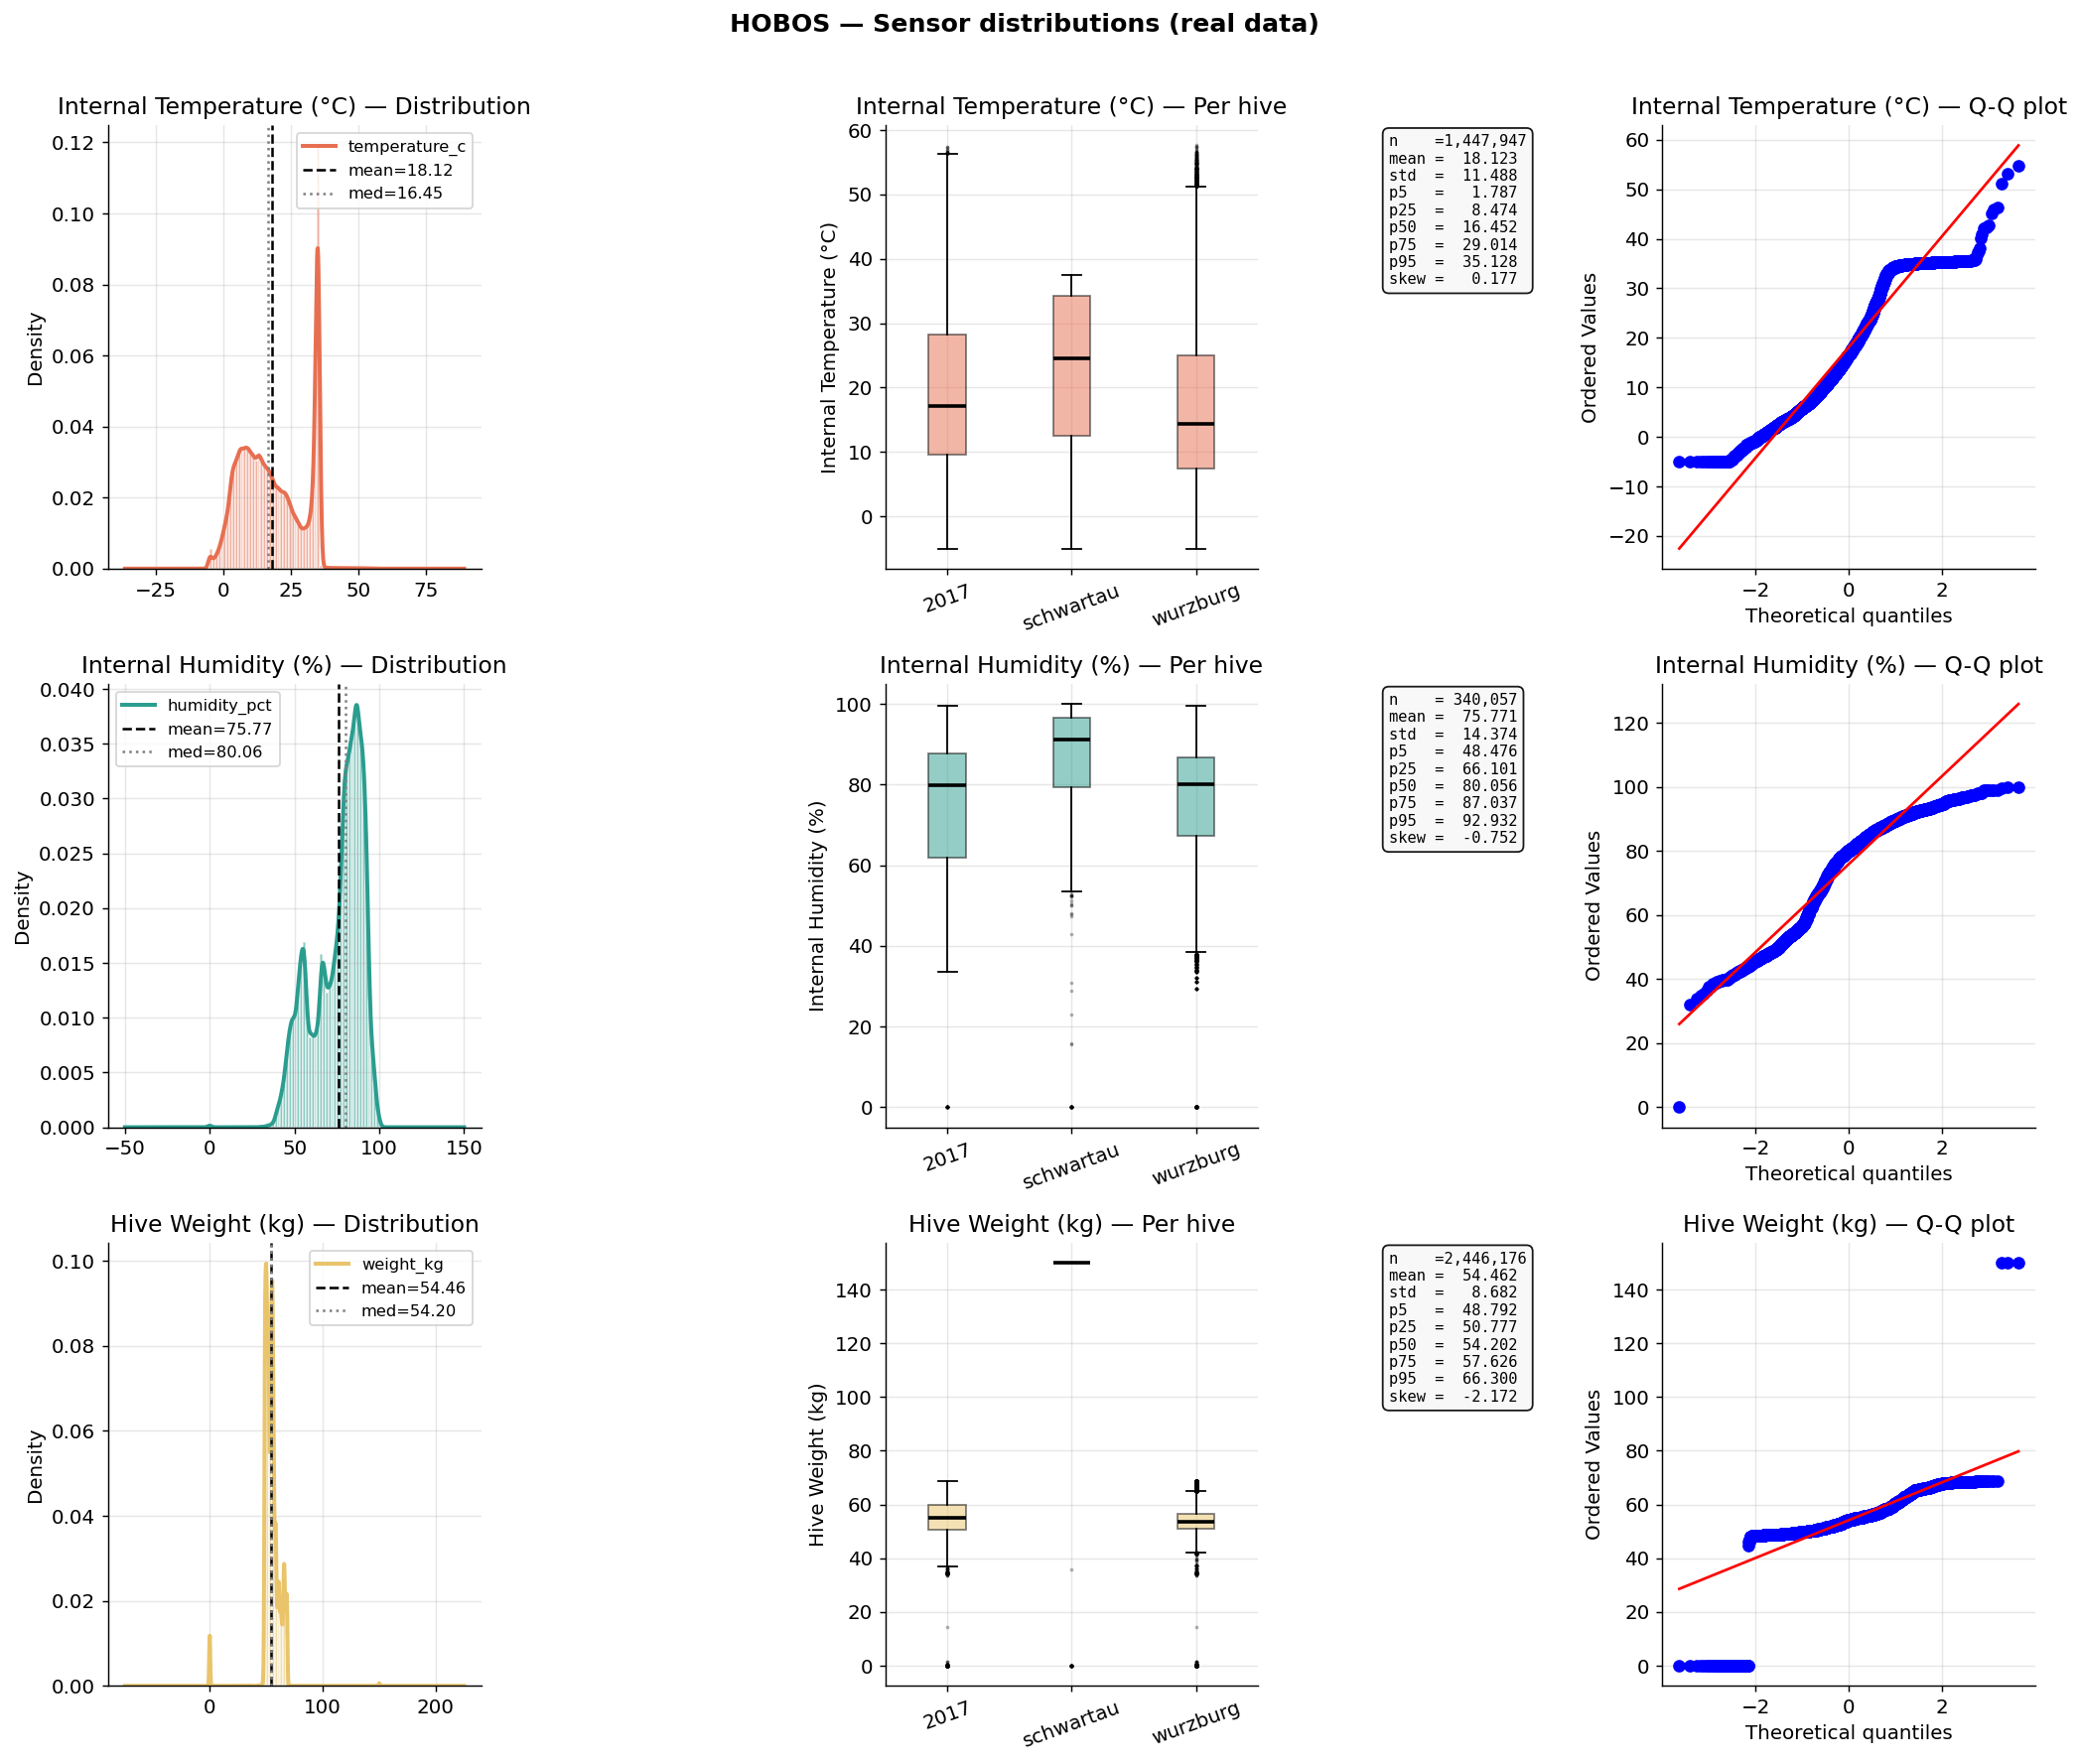

Saved: univariate_distributions.png


In [8]:
sensor_meta = [
    ('temperature_c', 'Internal Temperature (°C)'),
    ('humidity_pct',  'Internal Humidity (%)'),
    ('weight_kg',     'Hive Weight (kg)'),
]
available = [(col, label) for col, label in sensor_meta if col in df.columns]

fig, axes = plt.subplots(len(available), 3, figsize=(16, 4.5 * len(available)))
if len(available) == 1: axes = [axes]
fig.suptitle('HOBOS — Sensor distributions (real data)', fontsize=14, fontweight='bold', y=1.01)

for row, (col, label) in enumerate(available):
    color = PALETTE.get(col, PALETTE['neutral'])
    data  = df[col].dropna()

    # Histogram + KDE
    ax = axes[row][0]
    ax.hist(data, bins=60, color=color, alpha=0.55, edgecolor='white', density=True)
    data.plot.kde(ax=ax, color=color, linewidth=2.2)
    ax.axvline(data.mean(),   color='black', linestyle='--', lw=1.4, label=f'mean={data.mean():.2f}')
    ax.axvline(data.median(), color='gray',  linestyle=':',  lw=1.4, label=f'med={data.median():.2f}')
    ax.set_title(f'{label} — Distribution'); ax.set_ylabel('Density')
    ax.legend(fontsize=9)

    # Boxplot per hive
    ax2 = axes[row][1]
    hive_data = [df[df['hive']==h][col].dropna() for h in df['hive'].unique()]
    bp = ax2.boxplot(hive_data, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='.', ms=2, alpha=0.3))
    for patch in bp['boxes']: patch.set_facecolor(color); patch.set_alpha(0.5)
    ax2.set_xticklabels(df['hive'].unique(), rotation=20)
    ax2.set_title(f'{label} — Per hive'); ax2.set_ylabel(label)

    # Stats annotation
    stats_txt = (f"n    ={len(data):>8,}\n"
                 f"mean ={data.mean():>8.3f}\n"
                 f"std  ={data.std():>8.3f}\n"
                 f"p5   ={data.quantile(.05):>8.3f}\n"
                 f"p25  ={data.quantile(.25):>8.3f}\n"
                 f"p50  ={data.median():>8.3f}\n"
                 f"p75  ={data.quantile(.75):>8.3f}\n"
                 f"p95  ={data.quantile(.95):>8.3f}\n"
                 f"skew ={data.skew():>8.3f}")
    axes[row][1].text(1.35, 0.98, stats_txt, transform=axes[row][1].transAxes,
                      fontsize=8.5, va='top', fontfamily='monospace',
                      bbox=dict(boxstyle='round,pad=0.4', fc='#f8f8f8', alpha=0.9))

    # Q-Q
    ax3 = axes[row][2]
    stats.probplot(data.sample(min(5000, len(data)), random_state=42), plot=ax3)
    ax3.set_title(f'{label} — Q-Q plot')
    ax3.get_lines()[1].set_color('red')

plt.tight_layout()
plt.savefig(OUT_DIR / 'univariate_distributions.png')
plt.show()
print('Saved: univariate_distributions.png')

## 4. Temporal analysis — daily cycle & seasonality

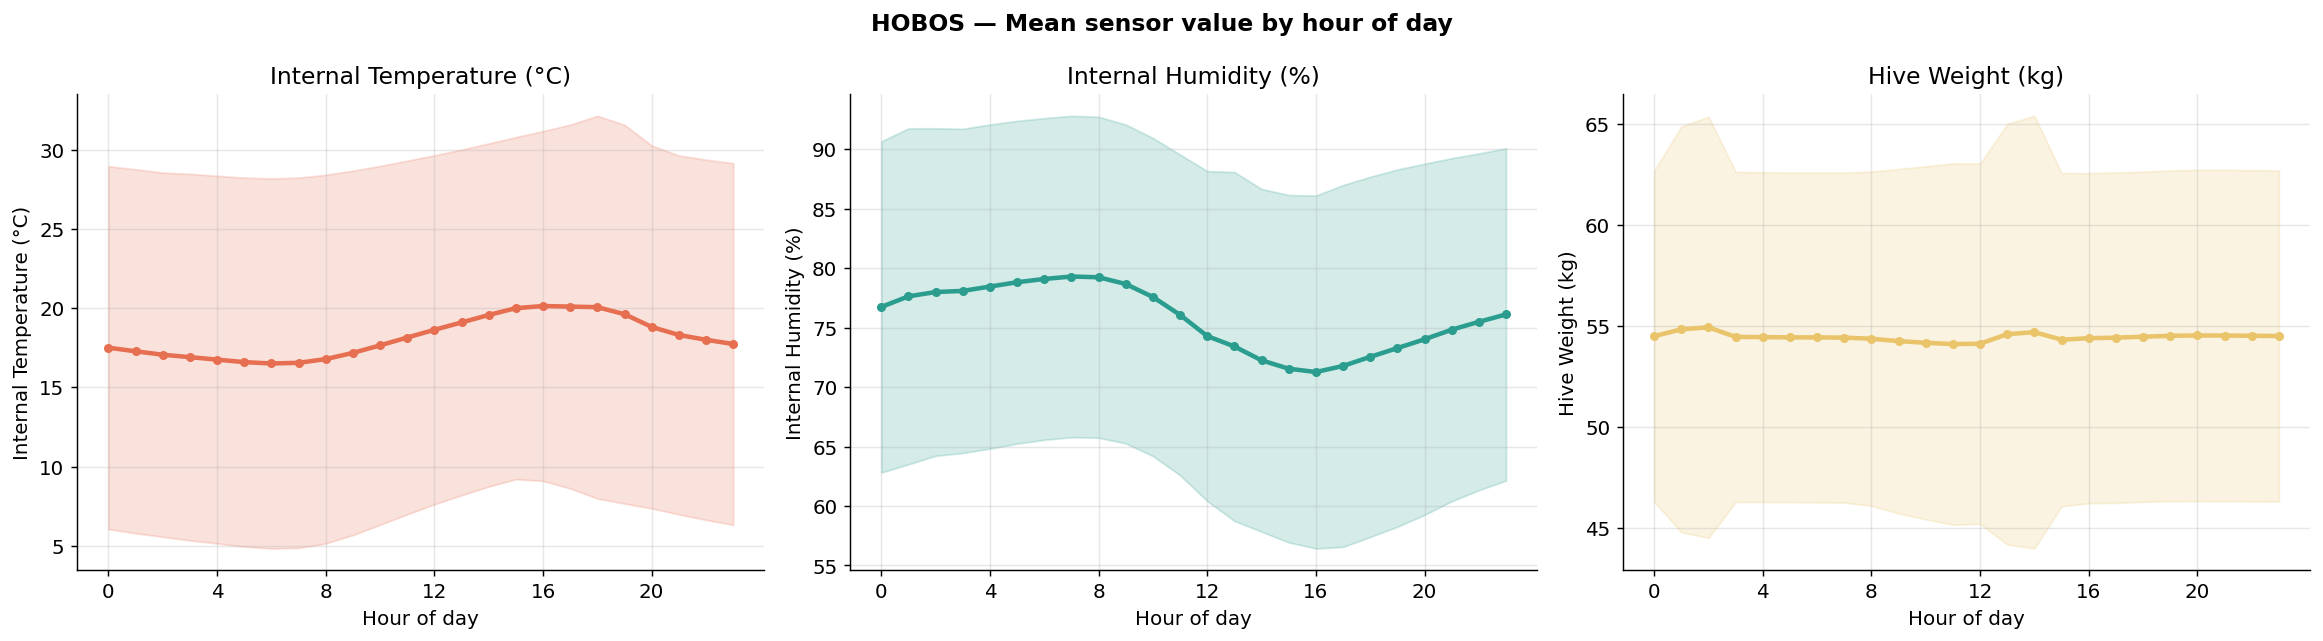

In [9]:
# Daily cycle
fig, axes = plt.subplots(1, len(available), figsize=(6 * len(available), 5))
if len(available) == 1: axes = [axes]
fig.suptitle('HOBOS — Mean sensor value by hour of day', fontsize=13, fontweight='bold')

for ax, (col, label) in zip(axes, available):
    color   = PALETTE.get(col, PALETTE['neutral'])
    hourly  = df.groupby('hour')[col].agg(['mean','std'])
    ax.plot(hourly.index, hourly['mean'], color=color, lw=2.5, marker='o', ms=4)
    ax.fill_between(hourly.index,
                    hourly['mean'] - hourly['std'],
                    hourly['mean'] + hourly['std'],
                    alpha=0.2, color=color)
    ax.set_xlabel('Hour of day'); ax.set_ylabel(label); ax.set_title(label)
    ax.set_xticks(range(0, 24, 4))

plt.tight_layout()
plt.savefig(OUT_DIR / 'daily_cycle.png')
plt.show()

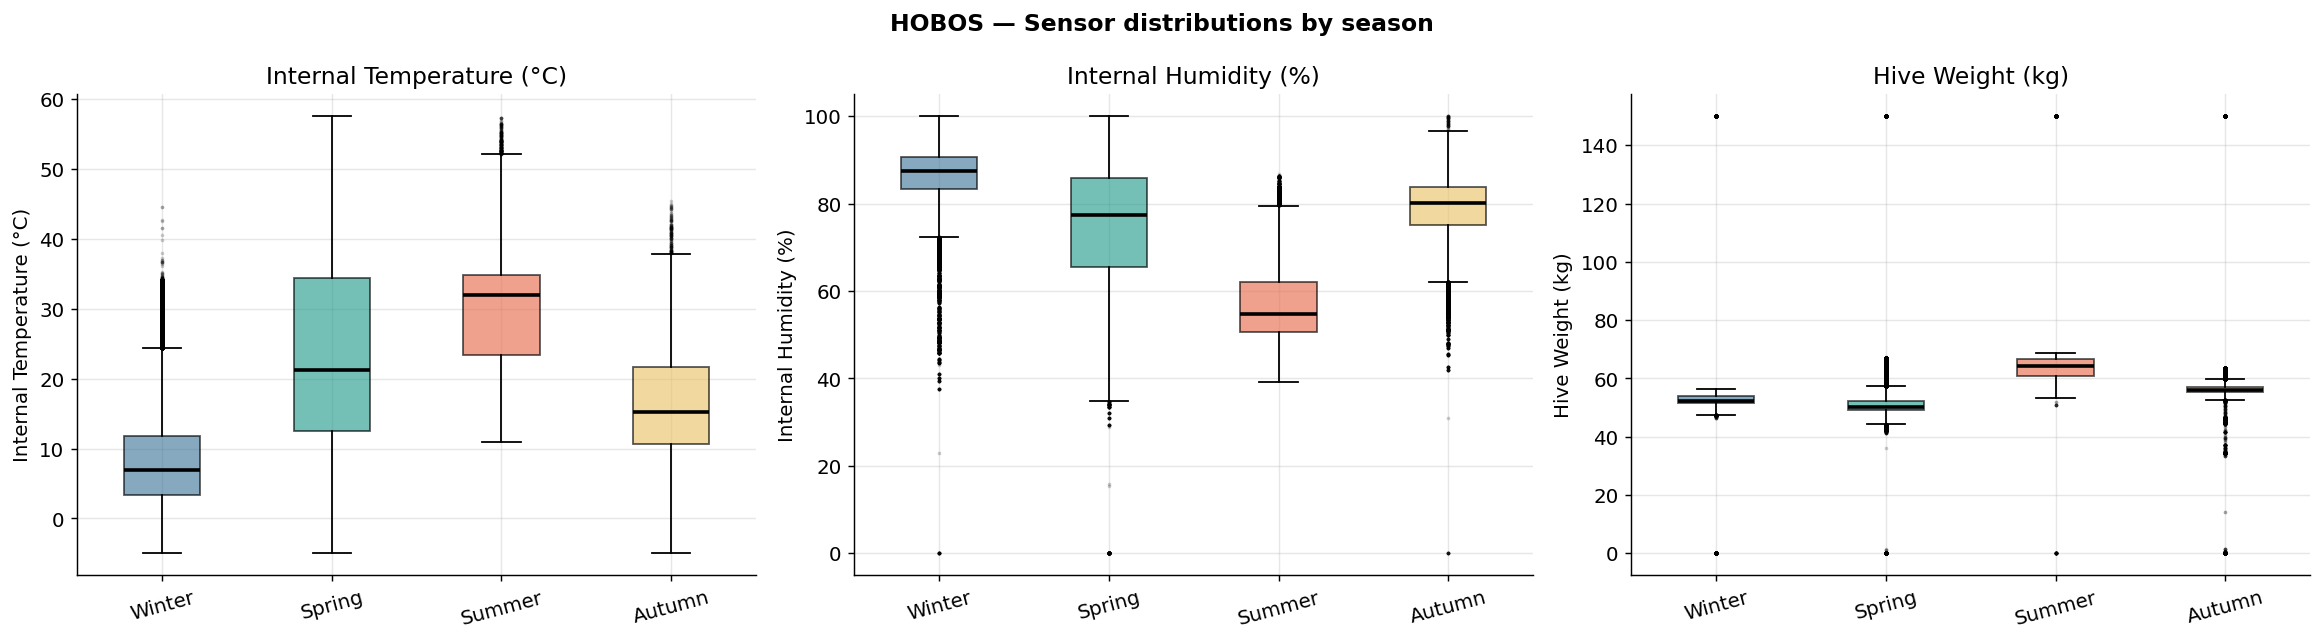

In [10]:
# Seasonal boxplots
season_order  = ['Winter','Spring','Summer','Autumn']
season_colors = {'Winter':'#457b9d','Spring':'#2a9d8f','Summer':'#e76f51','Autumn':'#e9c46a'}

fig, axes = plt.subplots(1, len(available), figsize=(6 * len(available), 5))
if len(available) == 1: axes = [axes]
fig.suptitle('HOBOS — Sensor distributions by season', fontsize=13, fontweight='bold')

for ax, (col, label) in zip(axes, available):
    present = [s for s in season_order if s in df['season_name'].values]
    data    = [df[df['season_name']==s][col].dropna() for s in present]
    bp = ax.boxplot(data, patch_artist=True,
                    medianprops=dict(color='black', lw=2),
                    flierprops=dict(marker='.', ms=2, alpha=0.2))
    for patch, s in zip(bp['boxes'], present):
        patch.set_facecolor(season_colors[s]); patch.set_alpha(0.65)
    ax.set_xticklabels(present, rotation=15)
    ax.set_ylabel(label); ax.set_title(label)

plt.tight_layout()
plt.savefig(OUT_DIR / 'seasonal_distributions.png')
plt.show()

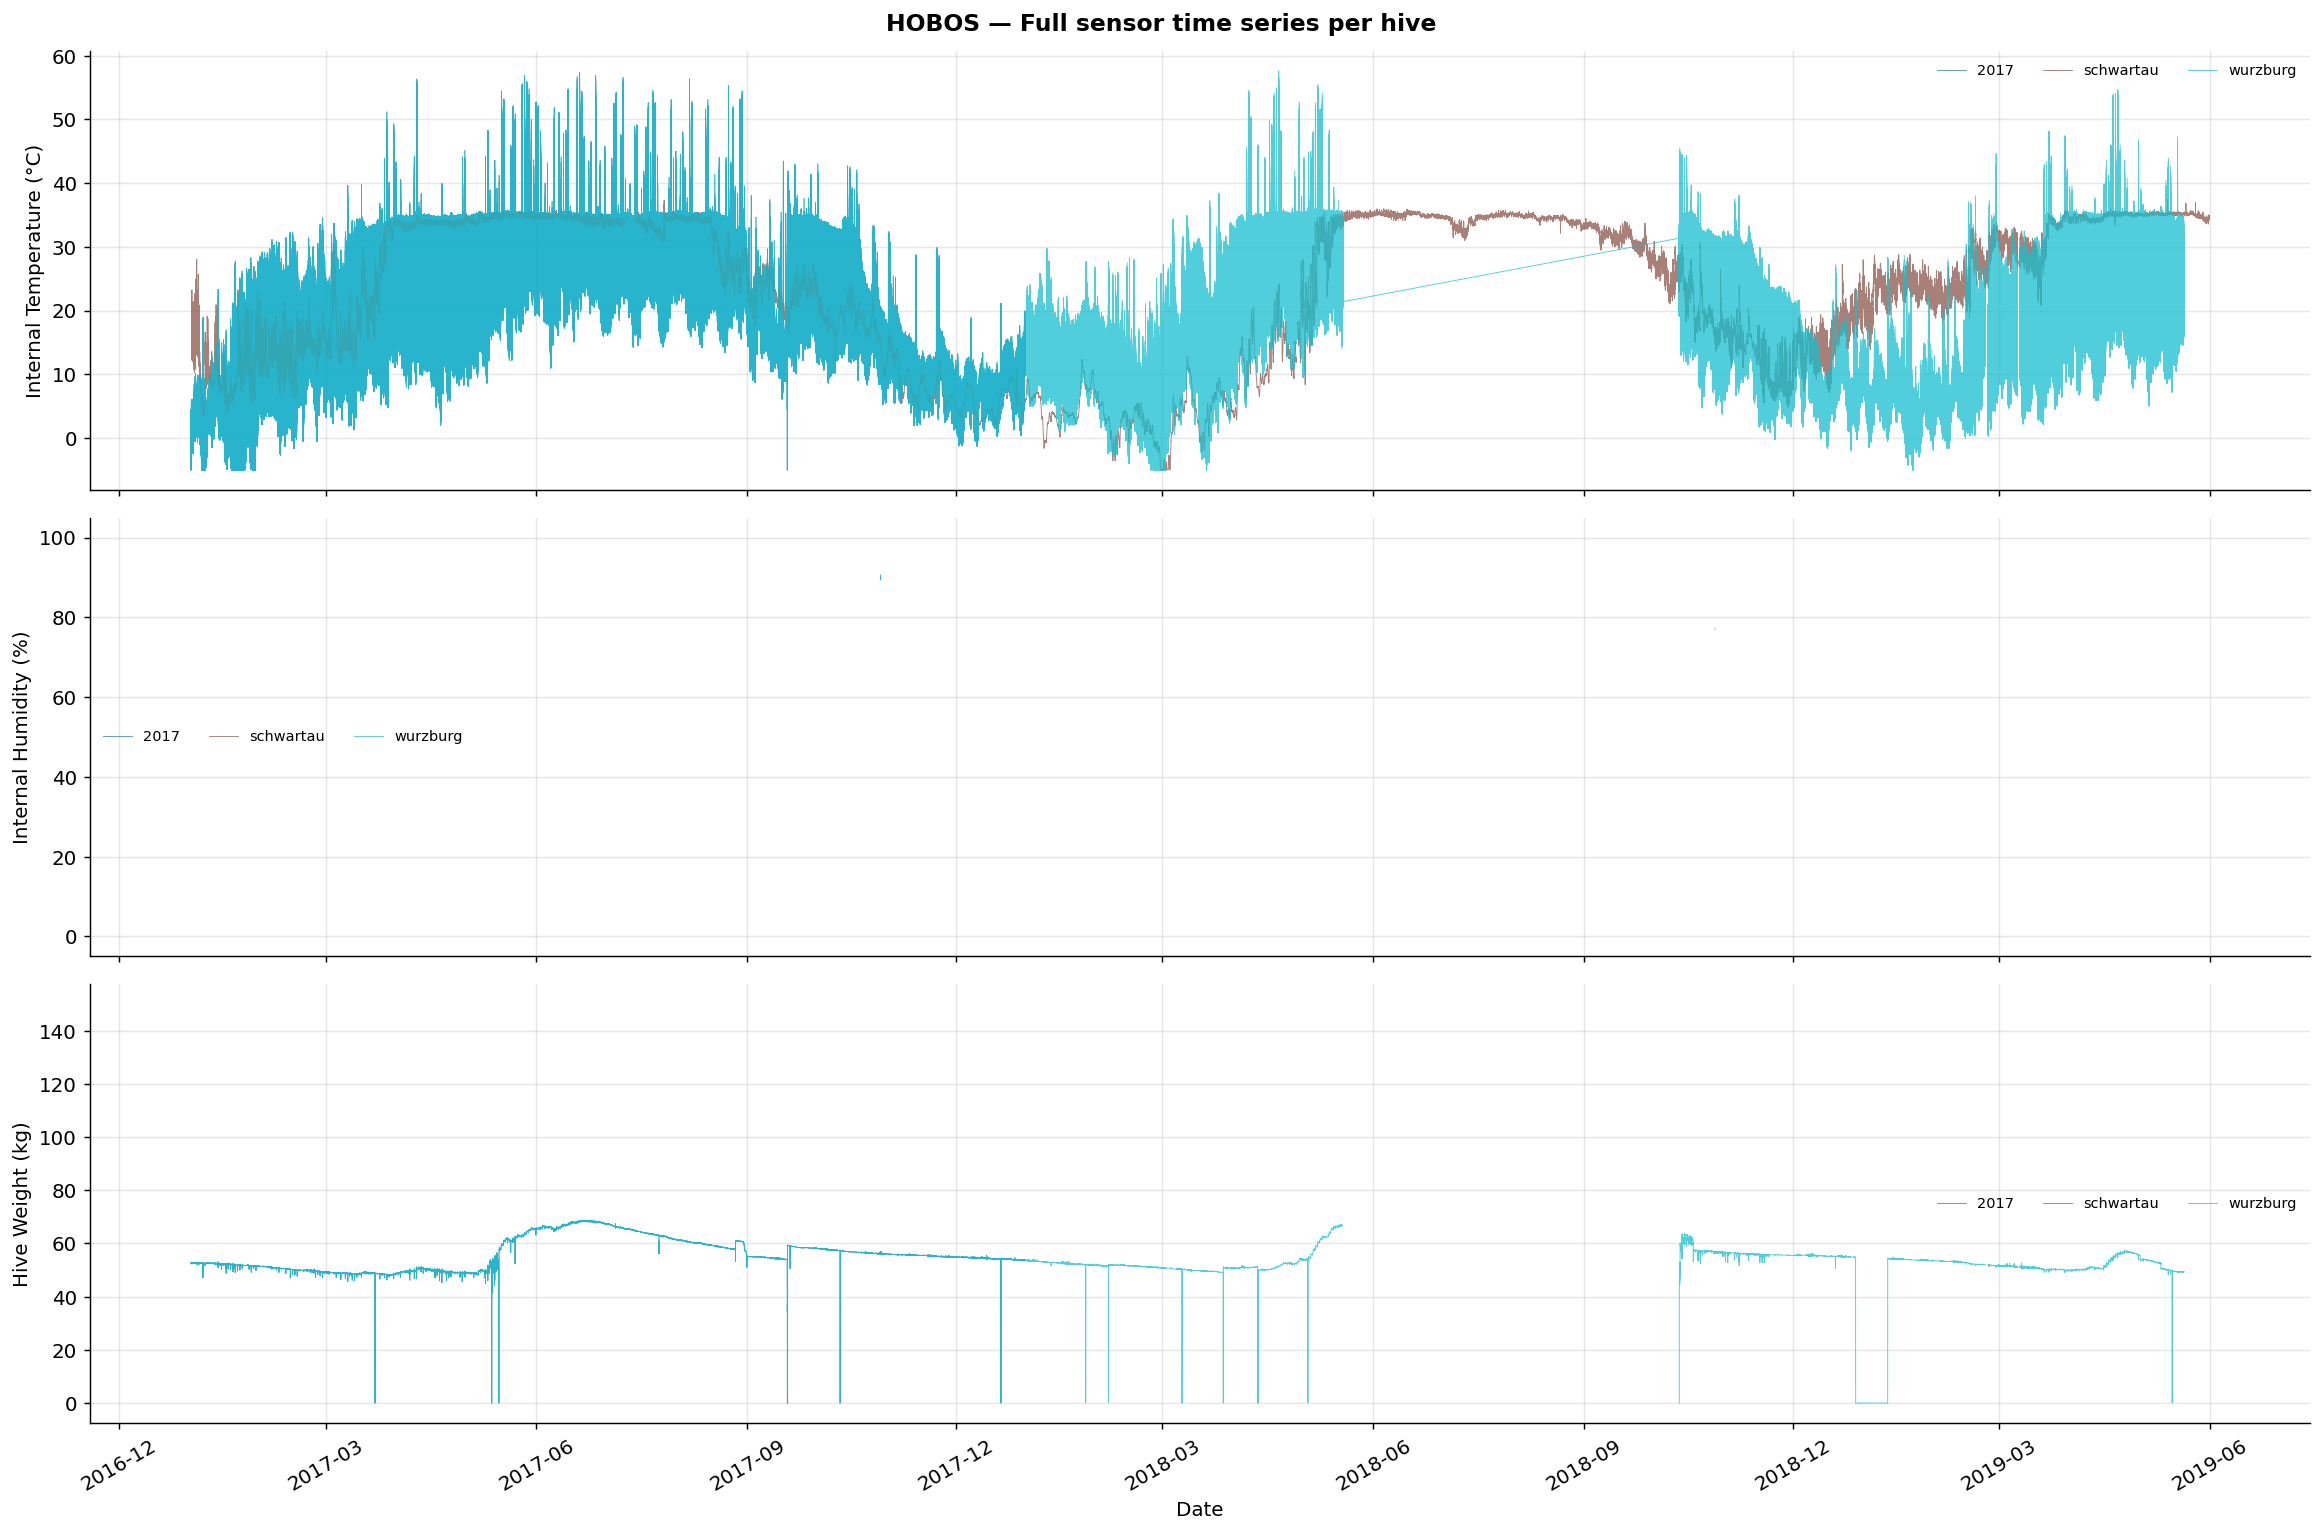

In [11]:
# Full time series — all hives overlaid
hive_colors = plt.cm.tab10(np.linspace(0, 1, df['hive'].nunique()))

fig, axes = plt.subplots(len(available), 1, figsize=(18, 4 * len(available)), sharex=True)
if len(available) == 1: axes = [axes]
fig.suptitle('HOBOS — Full sensor time series per hive', fontsize=13, fontweight='bold')

for ax, (col, label) in zip(axes, available):
    for i, (hive, grp) in enumerate(df.groupby('hive')):
        ax.plot(grp['ts'], grp[col], lw=0.5, alpha=0.75,
                color=hive_colors[i], label=hive)
    ax.set_ylabel(label)
    ax.legend(fontsize=8, ncol=4, frameon=False)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

axes[-1].set_xlabel('Date')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(OUT_DIR / 'full_timeseries.png')
plt.show()

## 5. Correlation & weight delta (swarming signatures)

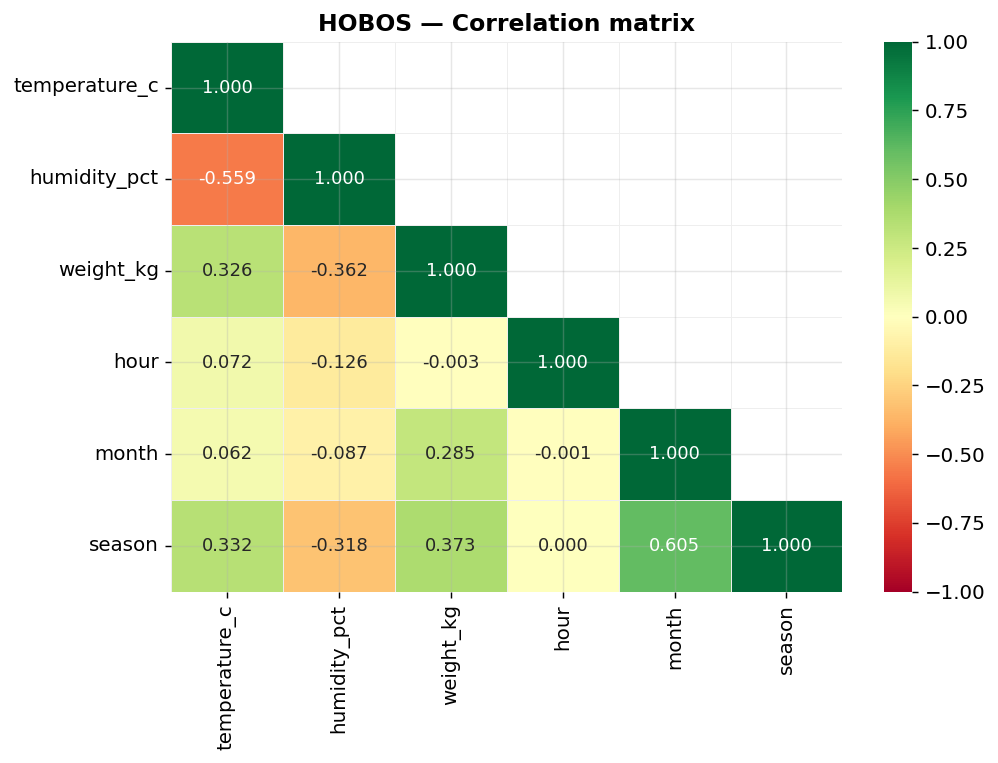

Top correlations:
  month ↔ season: r=0.6054
  temperature_c ↔ humidity_pct: r=-0.5593
  weight_kg ↔ season: r=0.3734
  humidity_pct ↔ weight_kg: r=-0.3617
  temperature_c ↔ season: r=0.3316
  temperature_c ↔ weight_kg: r=0.3262
  humidity_pct ↔ season: r=-0.3183
  weight_kg ↔ month: r=0.2854


In [12]:
# Correlation matrix
temporal_cols = [c for c in ['hour','month','season'] if c in df.columns]
corr_cols     = KEY_COLS + temporal_cols
corr          = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            vmin=-1, vmax=1, ax=ax, mask=mask,
            linewidths=0.5, linecolor='#eee', annot_kws={'size':10})
ax.set_title('HOBOS — Correlation matrix', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'correlation_matrix.png')
plt.show()

print('Top correlations:')
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack().sort_values(key=abs, ascending=False)
)
for (a, b), v in corr_pairs.head(8).items():
    print(f'  {a} ↔ {b}: r={v:.4f}')

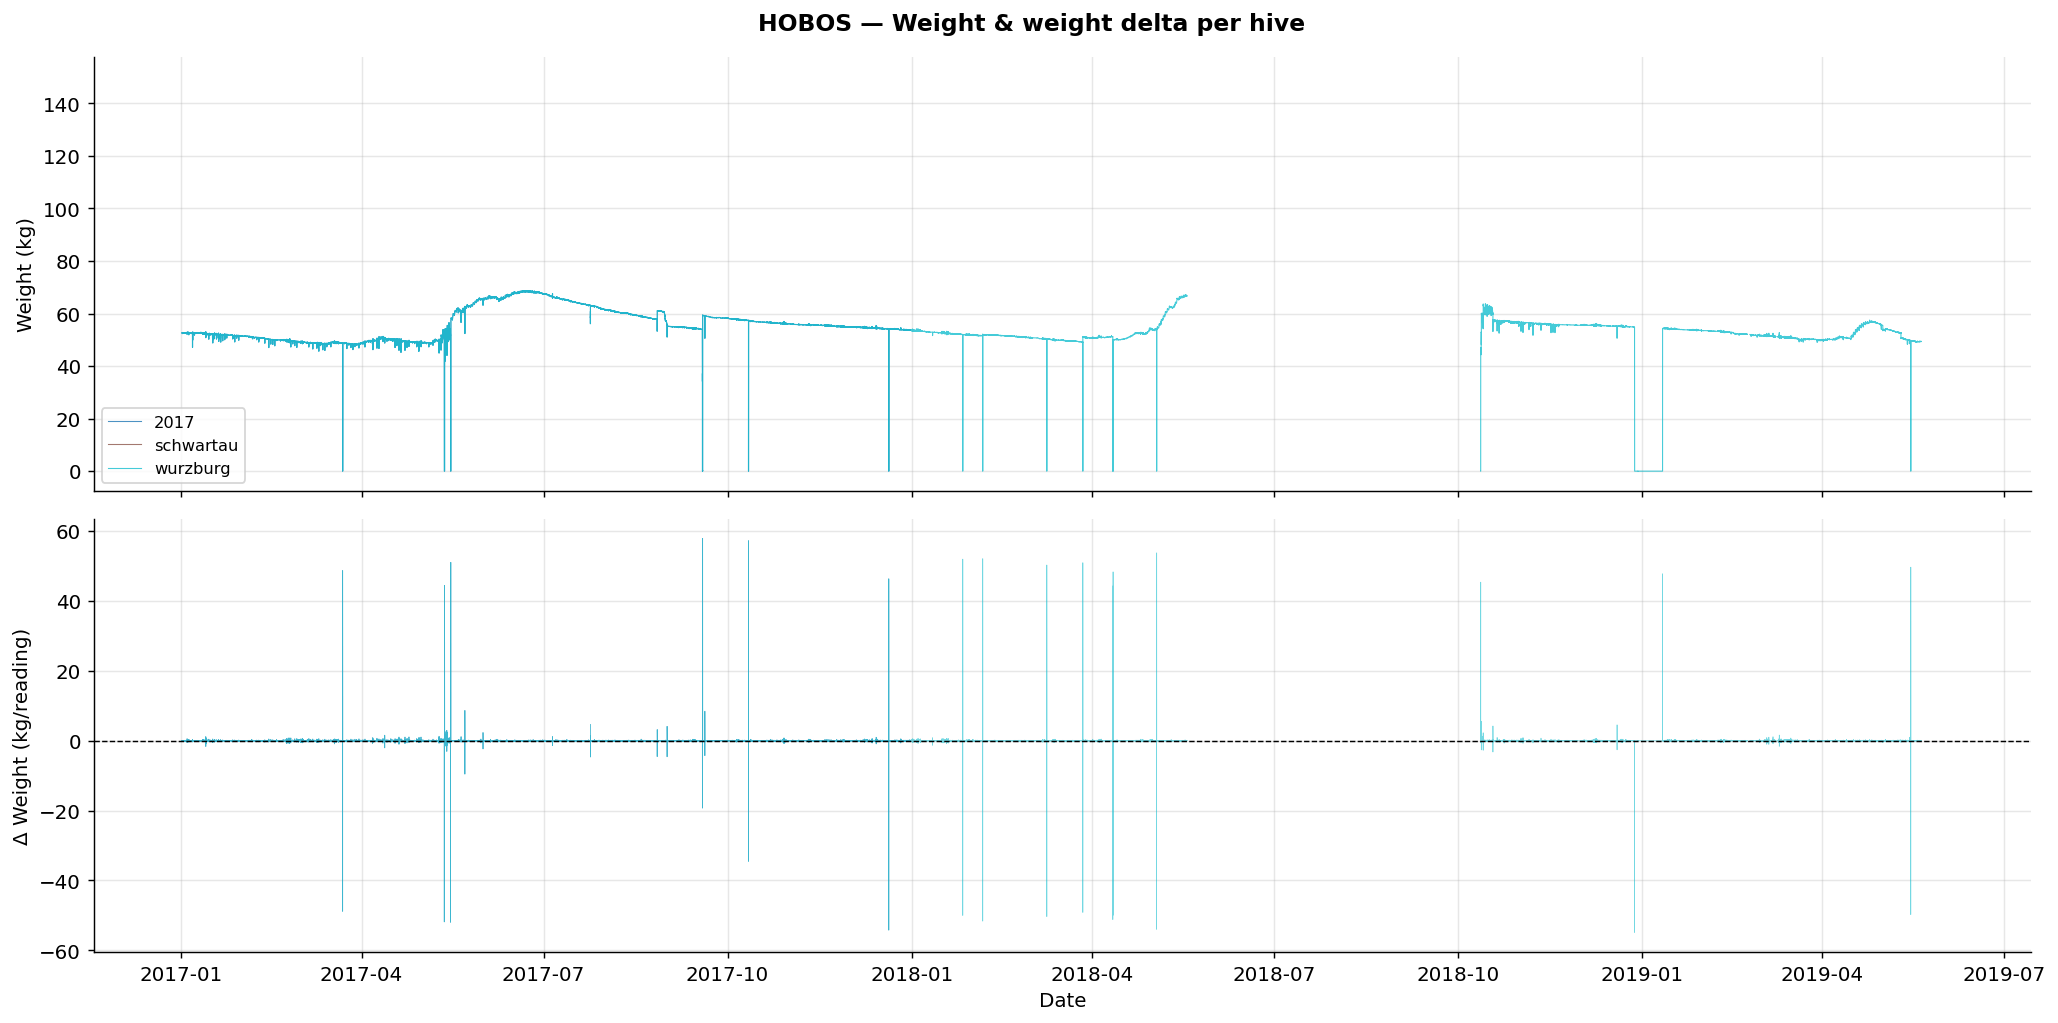

Weight delta stats (kg per reading interval):
  mean  = 0.00002 kg
  std   = 0.21210 kg
  p1    = -0.06410 kg   ← sharp drops (robbing / harvest)
  p99   = 0.06410 kg   ← sharp gains (nectar flow)
  min   = -54.87090 kg
  max   = 57.94640 kg


In [13]:
# Weight delta — key swarming / robbing / nectar-flow indicator
if 'weight_kg' in df.columns:
    df['weight_delta'] = df.groupby('hive')['weight_kg'].diff()

    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
    fig.suptitle('HOBOS — Weight & weight delta per hive', fontsize=13, fontweight='bold')

    for i, (hive, grp) in enumerate(df.groupby('hive')):
        axes[0].plot(grp['ts'], grp['weight_kg'],    lw=0.6, alpha=0.8,
                     color=hive_colors[i], label=hive)
        axes[1].plot(grp['ts'], grp['weight_delta'], lw=0.4, alpha=0.6,
                     color=hive_colors[i])

    axes[0].set_ylabel('Weight (kg)'); axes[0].legend(fontsize=9)
    axes[1].set_ylabel('Δ Weight (kg/reading)')
    axes[1].axhline(0, color='black', lw=0.8, ls='--')
    axes[-1].set_xlabel('Date')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'weight_delta.png')
    plt.show()

    delta = df['weight_delta'].dropna()
    print(f'Weight delta stats (kg per reading interval):')
    print(f'  mean  = {delta.mean():.5f} kg')
    print(f'  std   = {delta.std():.5f} kg')
    print(f'  p1    = {delta.quantile(.01):.5f} kg   ← sharp drops (robbing / harvest)')
    print(f'  p99   = {delta.quantile(.99):.5f} kg   ← sharp gains (nectar flow)')
    print(f'  min   = {delta.min():.5f} kg')
    print(f'  max   = {delta.max():.5f} kg')

## 6. Export calibration stats → `hobos_stats.json`

In [14]:
calib = {}

# Overall stats per sensor
calib['overall'] = {}
for col in KEY_COLS:
    d = df[col].dropna()
    calib['overall'][col] = {
        'mean': round(d.mean(), 4),
        'std' : round(d.std(),  4),
        'min' : round(d.min(),  4),
        'p5'  : round(d.quantile(.05), 4),
        'p25' : round(d.quantile(.25), 4),
        'p50' : round(d.median(),      4),
        'p75' : round(d.quantile(.75), 4),
        'p95' : round(d.quantile(.95), 4),
        'max' : round(d.max(),  4),
        'skew': round(float(d.skew()),     4),
        'kurt': round(float(d.kurtosis()), 4),
    }

# Per-season stats
calib['by_season'] = {}
for season in ['Winter','Spring','Summer','Autumn']:
    sub = df[df['season_name'] == season]
    if len(sub) == 0: continue
    calib['by_season'][season] = {}
    for col in KEY_COLS:
        d = sub[col].dropna()
        calib['by_season'][season][col] = {
            'mean': round(d.mean(), 4),
            'std' : round(d.std(),  4),
            'p5'  : round(d.quantile(.05), 4),
            'p95' : round(d.quantile(.95), 4),
        }

# Weight delta stats
if 'weight_delta' in df.columns:
    d = df['weight_delta'].dropna()
    calib['weight_delta'] = {
        'normal_mean'  : round(d[(d > -1) & (d < 1)].mean(), 6),
        'normal_std'   : round(d[(d > -1) & (d < 1)].std(),  6),
        'robbing_p1'   : round(d.quantile(.01),  5),
        'nectar_p99'   : round(d.quantile(.99),  5),
        'swarm_drop_p05': round(d.quantile(.005), 5),
    }

# Metadata
calib['meta'] = {
    'source'   : 'HOBOS via Kaggle (se18m502/bee-hive-metrics)',
    'n_rows'   : len(df),
    'hives'    : list(df['hive'].unique()),
    'date_range': [str(df.ts.min().date()), str(df.ts.max().date())],
    'sensors'  : KEY_COLS,
    'note'     : 'sound_level and door_open absent in HOBOS — calibrate from IBEE real data (210 Railway rows)',
}

out_path = OUT_DIR / 'hobos_stats.json'
with open(out_path, 'w') as f:
    json.dump(calib, f, indent=2)

print(f'✓ Exported: {out_path}')
print()
print('=== CALIBRATION SUMMARY ===')
for col in KEY_COLS:
    o = calib['overall'][col]
    print(f'  {col:<20}: mean={o["mean"]:>8.3f}  std={o["std"]:>7.3f}  range=[{o["p5"]:.2f}, {o["p95"]:.2f}]')
print()
print('Next step: upload hobos_stats.json to Claude → simulator recalibration')

✓ Exported: ../reports/figures/hobos_stats.json

=== CALIBRATION SUMMARY ===
  temperature_c       : mean=  18.122  std= 11.488  range=[1.79, 35.13]
  humidity_pct        : mean=  75.772  std= 14.373  range=[48.48, 92.93]
  weight_kg           : mean=  54.462  std=  8.682  range=[48.79, 66.30]

Next step: upload hobos_stats.json to Claude → simulator recalibration
